In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import snowflake.connector
from dotenv import load_dotenv
import os
import warnings
warnings.filterwarnings("ignore")

load_dotenv()

# Plot style
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

# Snowflake connection
conn = snowflake.connector.connect(
    user=os.getenv("SF_USER"),
    password=os.getenv("SF_PASSWORD"),
    account=os.getenv("SF_ACCOUNT"),
    database="STOCK_ANALYTICS",
    warehouse="COMPUTE_WH"
)
print("Connected to Snowflake")

Connected to Snowflake


In [2]:
# Load all analytical views
returns = pd.read_sql(
    "SELECT * FROM STOCK_ANALYTICS.ANALYTICS.V_DAILY_RETURNS ORDER BY DATE", conn)

volatility = pd.read_sql(
    "SELECT * FROM STOCK_ANALYTICS.ANALYTICS.V_VOLATILITY ORDER BY DATE", conn)

performance = pd.read_sql(
    "SELECT * FROM STOCK_ANALYTICS.ANALYTICS.V_CUMULATIVE_PERFORMANCE ORDER BY DATE", conn)

market_macro = pd.read_sql(
    "SELECT * FROM STOCK_ANALYTICS.ANALYTICS.V_MARKET_MACRO ORDER BY DATE", conn)

# Lowercase columns
for df in [returns, volatility, performance, market_macro]:
    df.columns = df.columns.str.lower()

print(f"Returns      : {len(returns)} rows")
print(f"Volatility   : {len(volatility)} rows")
print(f"Performance  : {len(performance)} rows")
print(f"Market macro : {len(market_macro)} rows")

Returns      : 9612 rows
Volatility   : 9606 rows
Performance  : 9612 rows
Market macro : 9606 rows


FileNotFoundError: [Errno 2] No such file or directory: 'docs/chart_performance.png'

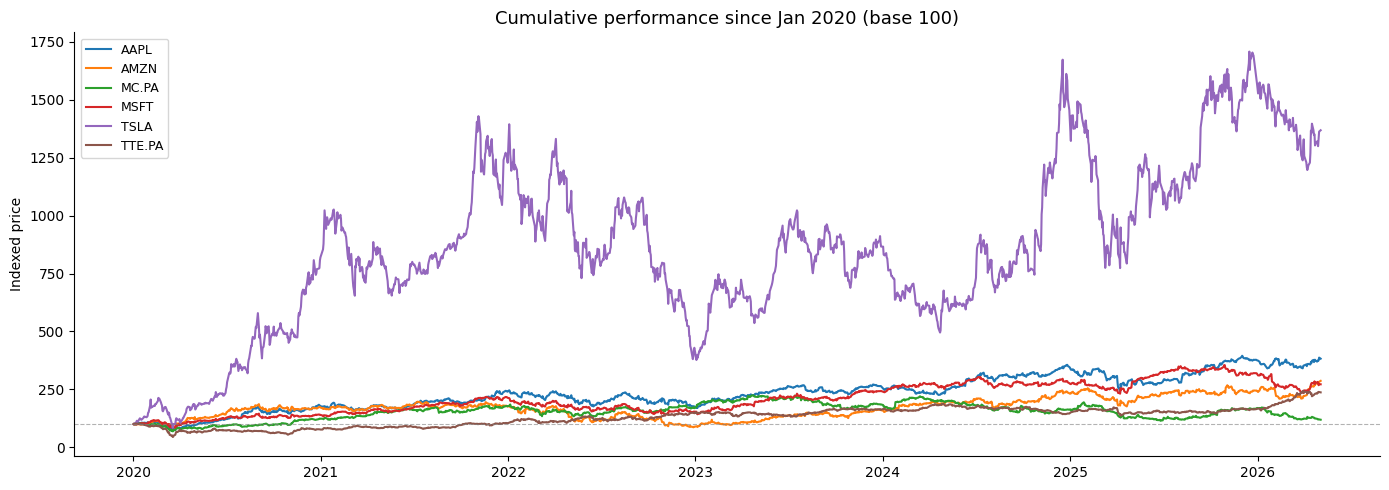

In [3]:
## Cumulative performance since Jan 2020 (base 100)

fig, ax = plt.subplots()

colors = {
    "AAPL"  : "#1f77b4",
    "AMZN"  : "#ff7f0e",
    "MC.PA" : "#2ca02c",
    "MSFT"  : "#d62728",
    "TSLA"  : "#9467bd",
    "TTE.PA": "#8c564b"
}

for ticker, group in performance.groupby("ticker"):
    group = group.sort_values("date")
    ax.plot(pd.to_datetime(group["date"]),
            group["indexed_price"],
            label=ticker,
            color=colors.get(ticker),
            linewidth=1.5)

ax.axhline(100, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)
ax.set_title("Cumulative performance since Jan 2020 (base 100)", fontsize=13)
ax.set_ylabel("Indexed price")
ax.legend(loc="upper left", fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.savefig("../docs/chart_performance.png", dpi=150)
plt.show()

In [ ]:
## 30-day rolling volatility by ticker

fig, ax = plt.subplots()

for ticker, group in volatility.groupby("ticker"):
    group = group.sort_values("date")
    ax.plot(pd.to_datetime(group["date"]),
            group["volatility_30d"],
            label=ticker,
            color=colors.get(ticker),
            linewidth=1.2,
            alpha=0.85)

ax.set_title("30-day rolling volatility by ticker", fontsize=13)
ax.set_ylabel("Volatility (std of daily returns %)")
ax.legend(loc="upper right", fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.tight_layout()
plt.savefig("../docs/chart_volatility.png", dpi=150)
plt.show()

In [ ]:
## Average annual return by ticker

returns["date"] = pd.to_datetime(returns["date"])
returns["year"] = returns["date"].dt.year

annual = (returns.groupby(["ticker", "year"])["daily_return_pct"]
          .mean()
          .reset_index()
          .rename(columns={"daily_return_pct": "avg_daily_return"}))

annual["annualized_return"] = annual["avg_daily_return"] * 252

pivot = annual.pivot(index="year", columns="ticker", values="annualized_return")

fig, ax = plt.subplots(figsize=(14, 6))
pivot.plot(kind="bar", ax=ax, color=list(colors.values()), width=0.75)

ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Annualized return by ticker and year (%)", fontsize=13)
ax.set_ylabel("Annualized return (%)")
ax.set_xlabel("")
ax.legend(loc="upper right", fontsize=9)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../docs/chart_annual_returns.png", dpi=150)
plt.show()

In [ ]:
## Correlation heatmap: market metrics vs macro indicators

macro_clean = market_macro.dropna(subset=["inflation", "fed_rate", "unemployment"])

corr_cols = ["daily_return_pct", "volatility_30d", "inflation", "fed_rate", "unemployment"]
corr = macro_clean[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr,
            annot=True,
            fmt=".2f",
            cmap="RdYlGn",
            center=0,
            linewidths=0.5,
            ax=ax)
ax.set_title("Correlation matrix: market vs macro indicators", fontsize=13)
plt.tight_layout()
plt.savefig("../docs/chart_correlation.png", dpi=150)
plt.show()

## Key Insights

### 1. Performance
- **TSLA** delivered the highest cumulative return but with extreme volatility
- **MSFT** and **AAPL** showed the best risk/return balance over the period
- **TTE.PA** (TotalEnergies) proved resilient during the 2022 energy crisis

### 2. Volatility
- Peak volatility observed in **March 2020** (COVID crash) for all tickers
- **TSLA** consistently shows 2-3x the volatility of other tickers
- European stocks (MC.PA, TTE.PA) show lower volatility than US tech

### 3. Macro correlations
- Rising **Fed Funds Rate** (2022–2023) correlates with increased market volatility
- **Inflation** shows weak direct correlation with daily returns
- **Unemployment** shows negative correlation with market returns as expected